# Image recognition study notebook (画像認識の勉強用notebook)


```



my_dataset/
├── apo_imgs_v1/
│   └── apo_images_new_model_v1/
├── apo_masks_v1/
│   └── apo_masks_new_model_v1/
├── fasc_imgs_v1/
│   └── fasc_images_new_model_v1/
├── fasc_masks_v1/
│   └── fasc_masks_new_model_v1/
├── test_images_v2/
│   └── test_set_v2/
└── sample_submission.csv


```

In [9]:
!mkdir -p content/my_dataset
!unzip -q umud-challenge-muscle-architecture-in-ultrasound-data.zip -d content/my_dataset/

"""
import sys
sys.path.append("/kaggle/input/competitions/umud-challenge-muscle-architecture-in-ultrasound-data")
"""

# function definition (関数定義)

In [12]:
from PIL import Image
import matplotlib.pyplot as plt
import os
import numpy as np
from collections import Counter


def image_mask(image_path, mask_path, image_name, mask_name):
    """
    image, mask, image+mask, 3枚描画
    """
    image = Image.open(image_path)
    mask = Image.open(mask_path)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title(image_name)
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(mask)
    plt.title(mask_name)
    plt.axis("off")

    plt.show()
    print("")

    mask_resized = mask.resize(image.size)

    plt.figure(figsize=(6, 5))
    plt.imshow(image)
    plt.imshow(mask_resized, alpha=0.4)
    plt.title(image_name + mask_name)
    plt.axis("off")
    plt.show()
    print("")


def check_mask(mask_dir, file_name, mask_name):
    """
    マスク画像のshape、dtype、unique値を確認
    """
    mask_array = np.array(
        Image.open(
            os.path.join(
                mask_dir,
                file_name
            )
        )
    )

    print(mask_name)
    print("shape:", mask_array.shape)
    print("dtype:", mask_array.dtype)
    print("unique:", np.unique(mask_array))
    print("")


def check_mask_palette(mask_dir, file_name, mask_name):
    """
    マスク画像のmode、画素数、paletteを確認する
    """

    mask = Image.open(
        os.path.join(
            mask_dir,
            file_name
        )
    )

    mask_array = np.array(mask)

    print(mask_name)
    print("mode:", mask.mode)
    print("0 pixels:", np.sum(mask_array == 0))
    print("255 pixels:", np.sum(mask_array == 255))

    palette = mask.getpalette()

    if palette is not None:
        print("palette[0]:", palette[0:3])
        print("palette[255]:", palette[255 * 3:255 * 3 + 3])
    else:
        print("palette: None")

    print("")


def check_mask_ratio(mask_dir, file_name, mask_name):
    """
    マスク画像の対象画素(255)の割合を確認する
    """
    mask_array = np.array(
        Image.open(
            os.path.join(
                mask_dir,
                file_name
            )
        )
    )

    total_pixels = mask_array.size
    target_pixels = np.sum(mask_array == 255)
    target_ratio = target_pixels / total_pixels * 100

    print(mask_name)
    print("total pixels:", total_pixels)
    print("target pixels:", target_pixels)
    print("target ratio:", target_ratio, "%")
    print("")


def check_all_masks(mask_dir, mask_name):
    """
    全マスク画像のmode、unique値、paletteを確認する
    """

    image_files = sorted([
        f for f in os.listdir(mask_dir)
        if f.lower().endswith((".tif", ".tiff", ".png", ".jpg", ".jpeg"))
    ])

    modes = set()
    unique_values = set()
    palettes = set()

    for file_name in image_files:

        mask = Image.open(
            os.path.join(
                mask_dir,
                file_name
            )
        )

        mask_array = np.array(mask)

        modes.add(mask.mode)

        unique_values.add(
            tuple(np.unique(mask_array))
        )

        palette = mask.getpalette()

        if palette is not None:
            palettes.add(
                (
                    tuple(palette[0:3]),
                    tuple(palette[255 * 3:255 * 3 + 3])
                )
            )
        else:
            palettes.add(None)

    print(mask_name)
    print("files:", len(image_files))
    print("modes:", modes)
    print("unique values:", unique_values)
    print("palettes:", palettes)
    print("")


def inspect_mask_patterns(mask_dir, mask_name):
    """
    マスクのmodeとunique値のパターン数を集計する
    """

    image_files = sorted([
        f for f in os.listdir(mask_dir)
        if f.lower().endswith((".tif", ".tiff", ".png", ".jpg", ".jpeg"))
    ])

    mode_counter = Counter()
    unique_counter = Counter()

    for file_name in image_files:

        mask = Image.open(
            os.path.join(
                mask_dir,
                file_name
            )
        )

        mask_array = np.array(mask)
        unique_values = tuple(np.unique(mask_array))

        mode_counter[mask.mode] += 1
        unique_counter[unique_values] += 1

    print(mask_name)
    print("files:", len(image_files))
    print("mode counts:", dict(mode_counter))
    print("unique counts:", dict(unique_counter))
    print("")


def find_mask_by_mode(mask_dir, target_mode):
    """
    指定したmodeのマスク画像を1枚探す
    """
    image_files = sorted([
        f for f in os.listdir(mask_dir)
        if f.lower().endswith((".tif", ".tiff", ".png", ".jpg", ".jpeg"))
    ])

    for file_name in image_files:
        mask = Image.open(
            os.path.join(
                mask_dir,
                file_name
            )
        )

        if mask.mode == target_mode:
            return file_name

    return None


def show_mask_values(mask_dir, file_name, mask_name):
    """
    マスク画像と、0/255の画素数を確認する
    """
    mask = Image.open(
        os.path.join(
            mask_dir,
            file_name
        )
    )

    mask_array = np.array(mask)

    print(mask_name)
    print("file:", file_name)
    print("mode:", mask.mode)
    print("unique:", np.unique(mask_array))
    print("0 pixels:", np.sum(mask_array == 0))
    print("255 pixels:", np.sum(mask_array == 255))
    print("")

    plt.figure(figsize=(6, 5))
    plt.imshow(mask, cmap="gray")
    plt.title(f"{mask_name} - {file_name}")
    plt.axis("off")
    plt.show()


def load_apo_binary_mask(mask_dir, file_name):
    """
    apo mask を
    背景=0
    aponeurosis=1
    の二値配列に変換する
    """

    mask = Image.open(
        os.path.join(
            mask_dir,
            file_name
        )
    )

    mask_array = np.array(mask)

    if mask.mode == "P":
        binary_mask = (mask_array == 0).astype(np.uint8)

    elif mask.mode == "L":
        binary_mask = (mask_array == 255).astype(np.uint8)

    else:
        raise ValueError(f"未対応のmodeです: {mask.mode}")

    return binary_mask


def load_fasc_binary_mask(mask_dir, file_name):
    """
    fasc mask を
    背景=0
    fascicle=1
    の二値配列に変換する
    """

    mask = Image.open(
        os.path.join(
            mask_dir,
            file_name
        )
    )

    mask_array = np.array(mask)

    if mask.mode == "L":
        binary_mask = (mask_array == 255).astype(np.uint8)

    else:
        raise ValueError(f"未対応のmodeです: {mask.mode}")

    return binary_mask


def compare_original_binary(mask_dir, file_name, binary_mask, mask_name):
    """
    変換前maskと二値化後maskを並べて確認する
    """

    original_mask = Image.open(
        os.path.join(
            mask_dir,
            file_name
        )
    )

    original_array = np.array(original_mask)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(original_mask, cmap="gray")
    plt.title(mask_name + " original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(binary_mask, cmap="gray")
    plt.title(mask_name + " binary")
    plt.axis("off")

    plt.show()

    print("original unique:", np.unique(original_array))
    print("binary unique:", np.unique(binary_mask))
    print("")

# Check data structure(データ構造の確認)

In [14]:

data_dir = "content/my_dataset"
apo_images_new_model_v1 = os.path.join(data_dir, "apo_imgs_v1", "apo_images_new_model_v1")
apo_masks_new_model_v1 = os.path.join(data_dir, "apo_masks_v1", "apo_masks_new_model_v1")
fasc_images_new_model_v1 = os.path.join(data_dir,"fasc_imgs_v1", "fasc_images_new_model_v1")
fasc_masks_new_model_v1 = os.path.join(data_dir, "fasc_masks_v1", "fasc_masks_new_model_v1")
test_set_v2 = os.path.join(data_dir, "test_images_v2", "test_set_v2")



print(f"""
------------------------------------
データセット

{os.listdir(data_dir)}

------------------------------------
apo_imgs_v1/apo_images_new_model_v1

{sorted(os.listdir(apo_images_new_model_v1))[0:3]}....

------------------------------------
apo_masks_v1/apo_masks_new_model_v1

{sorted(os.listdir(apo_masks_new_model_v1))[0:3]}....

------------------------------------
fasc_imgs_v1/fasc_images_new_model_v1

{sorted(os.listdir(fasc_images_new_model_v1 ))[0:3]}....

------------------------------------
fasc_masks_v1/fasc_masks_new_model_v1

{sorted(os.listdir(fasc_masks_new_model_v1))[0:3]}....

------------------------------------
test_images_v2/test_set_v2

{sorted(os.listdir(test_set_v2))[0:3]}....

------------------------------------

""")


------------------------------------
データセット

['test_images_v2', 'fasc_masks_v1', 'apo_imgs_v1', 'fasc_imgs_v1', 'apo_masks_v1', 'sample_submission.csv']

------------------------------------
apo_imgs_v1/apo_images_new_model_v1

['Thumbs.db', 'image_0000.tif', 'image_0001.tif']....

------------------------------------
apo_masks_v1/apo_masks_new_model_v1

['image_0000.tif', 'image_0001.tif', 'image_0002.tif']....

------------------------------------
fasc_imgs_v1/fasc_images_new_model_v1

['Thumbs.db', 'image_0000.tif', 'image_0001.tif']....

------------------------------------
fasc_masks_v1/fasc_masks_new_model_v1

['image_0000.tif', 'image_0001.tif', 'image_0002.tif']....

------------------------------------
test_images_v2/test_set_v2

['IMG_00001.tif', 'IMG_00002.tif', 'IMG_00003.tif']....

------------------------------------




# Loading images(画像の読み込み)

画像パス: content/my_dataset/apo_imgs_v1/apo_images_new_model_v1/image_0000.tif
画像サイズ: (1200, 800)
画像モード: RGB


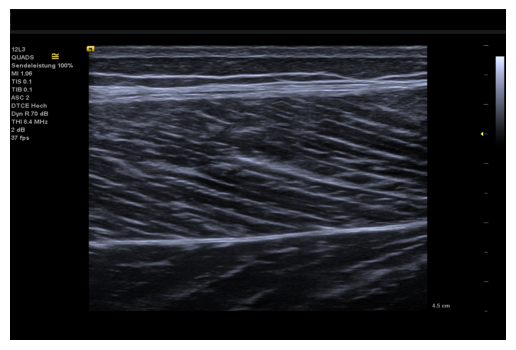

In [15]:
image_path = os.path.join(apo_images_new_model_v1, sorted(os.listdir(apo_images_new_model_v1))[1])
image = Image.open(image_path)

print("画像パス:", image_path)
print("画像サイズ:", image.size)
print("画像モード:", image.mode)

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

In [16]:
image_array = np.array(image)

print("shape:", image_array.shape)
print("dtype:", image_array.dtype)
print("min:", image_array.min())
print("max:", image_array.max())

shape: (800, 1200, 3)
dtype: uint8
min: 0
max: 255



|1|2|3|
|--------|--------|--------|
|shape|800, 1200, 3|高さ800、幅1200、RGB 3チャンネル|
|dtype|uint8|1画素あたり0〜255の整数|
|min<br>max|0<br>255|画像の画素値範囲は0〜255|


# Check the image(画像の確認)


* **apo** は aponeurosis（腱膜）を指しています。
UMUD公式資料では、超音波画像の中に superficial aponeurosis（表層腱膜）deep aponeurosis（深部腱膜）が写っており、この2本の構造が筋厚などの計測に使われます

* **fasc** は fascicle（筋束）を指します。Kaggle公式では、筋束は超音波画像内で「筋腹の中を斜めに走る高エコーの線」と説明されています。

* xx_imgs_v1は検出用の学習画像、xx_masks_v1 はその画像のどこかを示す正解マスクです。


<br>

---


<br>

* apo refers to aponeurosis.
UMUD official materials show the superficial aponeurosis and deep aponeurosis in the ultrasound image, and these two structures are used to measure muscle thickness, etc.

* Fasc refers to muscle fascicles. According to Kaggle's official website, muscle fascicles are described as ``high-echo lines running diagonally through the muscle bellies'' in ultrasound images.

* xx_imgs_v1 is the training image for detection, and xx_masks_v1 is the ground truth mask that indicates somewhere in the image.

In [17]:
image_files = sorted([
    f for f in os.listdir(apo_images_new_model_v1)
    if f.lower().endswith((".tif", ".tiff", ".png", ".jpg", ".jpeg"))
])

mask_files = sorted([
    f for f in os.listdir(apo_masks_new_model_v1)
    if f.lower().endswith((".tif", ".tiff", ".png", ".jpg", ".jpeg"))
])

for image_name, mask_name in zip(image_files[:10], mask_files[:10]):

    image_path = os.path.join(apo_images_new_model_v1, image_name)
    mask_path = os.path.join(apo_masks_new_model_v1, mask_name)

    image = Image.open(image_path)
    mask = Image.open(mask_path)

    print(
        image_name,
        "image:", image.size,
        "mask:", mask.size
    )

image_0000.tif image: (1200, 800) mask: (1152, 864)
image_0001.tif image: (1200, 800) mask: (1152, 864)
image_0002.tif image: (1200, 800) mask: (1152, 864)
image_0003.tif image: (1200, 800) mask: (1152, 864)
image_0004.tif image: (1200, 800) mask: (1152, 864)
image_0005.tif image: (1200, 800) mask: (1152, 864)
image_0006.tif image: (1200, 800) mask: (1152, 864)
image_0007.tif image: (1200, 800) mask: (1152, 864)
image_0008.tif image: (1200, 800) mask: (1152, 864)
image_0009.tif image: (1200, 800) mask: (1152, 864)



apo は aponeurosis（腱膜）を指しています。
UMUD公式資料では、超音波画像の中に superficial aponeurosis（表層腱膜）deep aponeurosis（深部腱膜）が写っており、この2本の構造が筋厚などの計測に使われます




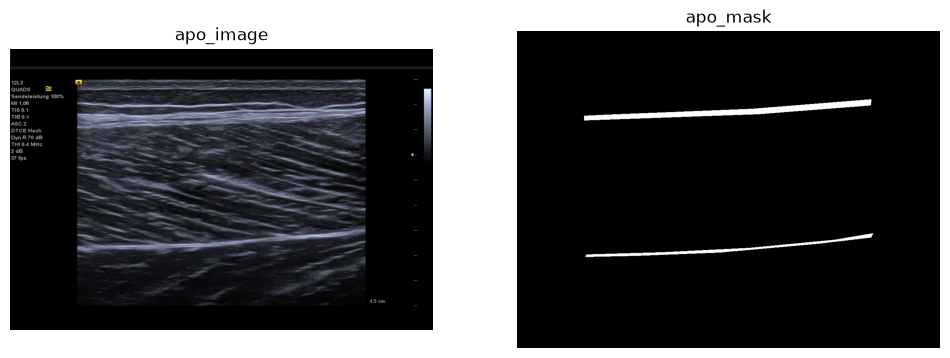

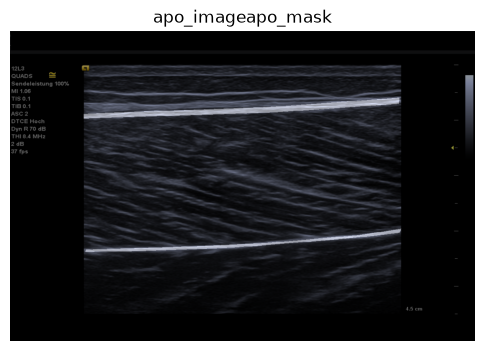



fasc は fascicle（筋束）を指します。Kaggle公式では、筋束は超音波画像内で「筋腹の中を斜めに走る高エコーの線」と説明されています。



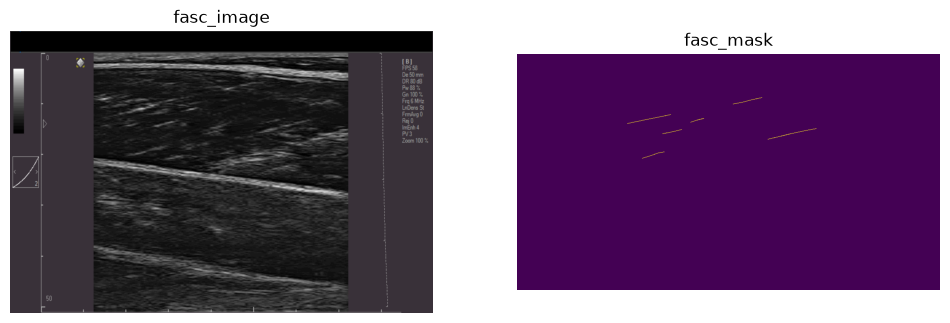

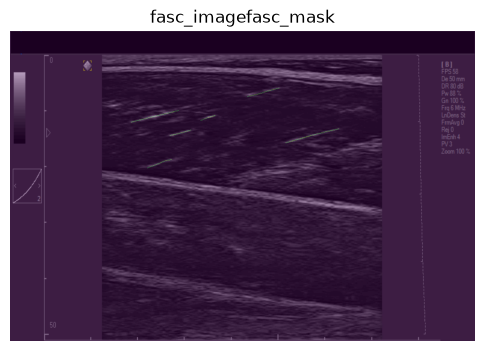

In [18]:
print("""
apo は aponeurosis（腱膜）を指しています。
UMUD公式資料では、超音波画像の中に superficial aponeurosis（表層腱膜）deep aponeurosis（深部腱膜）が写っており、この2本の構造が筋厚などの計測に使われます

""")
image_mask(
    os.path.join(apo_images_new_model_v1, "image_0000.tif"),
    os.path.join(apo_masks_new_model_v1, "image_0000.tif"),
    "apo_image",
    "apo_mask",
    )


print("""
fasc は fascicle（筋束）を指します。Kaggle公式では、筋束は超音波画像内で「筋腹の中を斜めに走る高エコーの線」と説明されています。
""")
image_mask(
    os.path.join(fasc_images_new_model_v1, "image_0000.tif"),
    os.path.join(fasc_masks_new_model_v1, "image_0000.tif"),
    "fasc_image",
    "fasc_mask",
)

* apo mask
→ superficial / deep aponeurosis の位置

* fasc mask
→ fascicle の位置

* これらの構造
→ PA / FL / MT の推定に関係

* 資料では PA は fascicle と deep aponeurosis の角度、FL は両 aponeurosis 間の fascicle length、MT は両 aponeurosis 間の垂直距離と定義されています。

# Check color space(色空間の確認)

*  「L」モード (Luminance):

8bitのグレースケール（白黒）画像<br>
1つのピクセルに対して、0（黒）から255（白）までの1つの数値（輝度）だけを持ちます

<br>

* 「P」モード (Palette)

パレットカラー（インデックスカラー）画像<br>
ピクセルそのものにはRGBの色を持たず、「0番の色」「1番の色」という色の背番号（インデックス）だけを持ちます。別に用意された「カラーパレット（色の辞書）」を参照して色を表現します。最大256色まで扱えます


<br>

----

<br>

* "L" mode (Luminance):
8bit grayscale (black and white) image
Each pixel has only one number (brightness) from 0 (black) to 255 (white)

* "P" mode (Palette)
Palette color (index color) image
The pixels themselves do not have RGB colors, but only have color numbers (indexes) such as "color 0" and "color 1." Express colors by referring to a separately prepared "color palette (color dictionary)". Can handle up to 256 colors

In [19]:
print("========================shape、dtype、unique値========================")
check_mask(apo_masks_new_model_v1, "image_0000.tif", "apo mask")
check_mask(fasc_masks_new_model_v1, "image_0000.tif", "fasc mask")

print("========================mode、画素数、palette========================")
check_mask_palette(apo_masks_new_model_v1, "image_0000.tif", "apo mask")
check_mask_palette(fasc_masks_new_model_v1, "image_0000.tif", "fasc mask")

print("========================255の割合========================")
check_mask_ratio(apo_masks_new_model_v1, "image_0000.tif", "apo mask")
check_mask_ratio(fasc_masks_new_model_v1, "image_0000.tif", "fasc mask")

print("========================全マスク画像のmode、unique値、palette========================")
check_all_masks(apo_masks_new_model_v1, "apo masks")
check_all_masks(fasc_masks_new_model_v1, "fasc masks")

print("========================マスクのmodeとunique値のパターン数を集計========================")
inspect_mask_patterns(apo_masks_new_model_v1, "apo masks")
inspect_mask_patterns(fasc_masks_new_model_v1, "fasc masks")

========================shape、dtype、unique値========================
apo mask
shape: (864, 1152)
dtype: uint8
unique: [  0 255]

fasc mask
shape: (556, 996)
dtype: uint8
unique: [  0 255]

========================mode、画素数、palette========================
apo mask
mode: P
0 pixels: 17766
255 pixels: 977562
palette[0]: [255, 255, 255]
palette[255]: [0, 0, 0]

fasc mask
mode: L
0 pixels: 553343
255 pixels: 433
palette: None

========================255の割合========================
apo mask
total pixels: 995328
target pixels: 977562
target ratio: 98.21506076388889 %

fasc mask
total pixels: 553776
target pixels: 433
target ratio: 0.07819045968044841 %

========================全マスク画像のmode、unique値、palette========================
apo masks
files: 1048
modes: {'P', 'L'}
unique values: {(np.uint8(0), np.uint8(255))}
palettes: {None, ((255, 255, 255), (0, 0, 0))}

fasc masks
files: 2761
modes: {'L'}
unique values: {(np.uint8(0),), (np.uint8(0), np.uint8(255))}
palettes: {None}

=====================

* apo は P/L が混在
* apo は全件で 0/255 の二値
* fasc は全件 L
* fasc のうち5枚は全画素0

----

* apo has mixed P/L
* apo is a binary value of 0/255 for all cases.
* fasc is all L
* All pixels in 5 of fasc are 0

apo P mask
file: image_0000.tif
mode: P
unique: [  0 255]
0 pixels: 17766
255 pixels: 977562



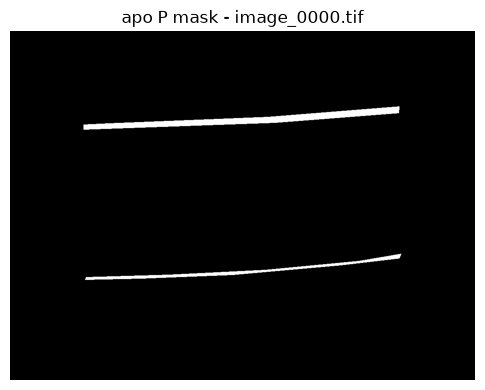

apo L mask
file: image_0428.tif
mode: L
unique: [  0 255]
0 pixels: 465630
255 pixels: 14370



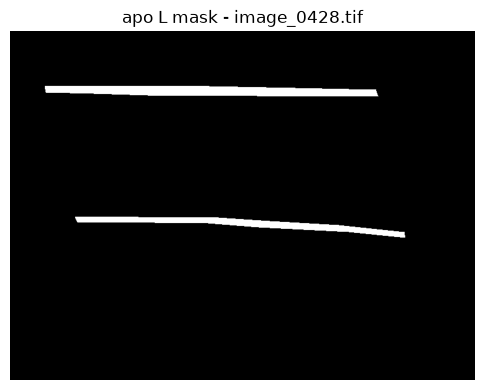

In [20]:
#Find one mask image of the specified mode  (指定したmodeのマスク画像を1枚探す)
apo_p_file = find_mask_by_mode(apo_masks_new_model_v1, "P")
apo_l_file = find_mask_by_mode(apo_masks_new_model_v1, "L")

#Check the mask image and the number of pixels of 0/255(マスク画像と、0/255の画素数を確認する)
show_mask_values(apo_masks_new_model_v1, apo_p_file, "apo P mask")
show_mask_values(apo_masks_new_model_v1, apo_l_file, "apo L mask")

* apo P mode
```
0   = aponeurosis

255 = background
```
<br>

* apo L mode
```
0   = background

255 = aponeurosis
```


# Unification of color space(色空間の統一)

## apo

In [21]:
apo_binary_mask = load_apo_binary_mask(
    apo_masks_new_model_v1,
    "image_0000.tif"
)

print("shape:", apo_binary_mask.shape)
print("dtype:", apo_binary_mask.dtype)
print("unique:", np.unique(apo_binary_mask))

shape: (864, 1152)
dtype: uint8
unique: [0 1]


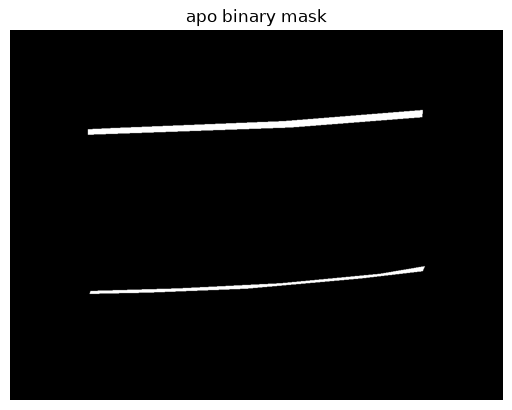

In [22]:
plt.imshow(apo_binary_mask, cmap="gray")
plt.title("apo binary mask")
plt.axis("off")
plt.show()

## fasc

In [23]:
fasc_binary_mask = load_fasc_binary_mask(
    fasc_masks_new_model_v1,
    "image_0000.tif"
)

print("shape:", fasc_binary_mask.shape)
print("dtype:", fasc_binary_mask.dtype)
print("unique:", np.unique(fasc_binary_mask))

shape: (556, 996)
dtype: uint8
unique: [0 1]


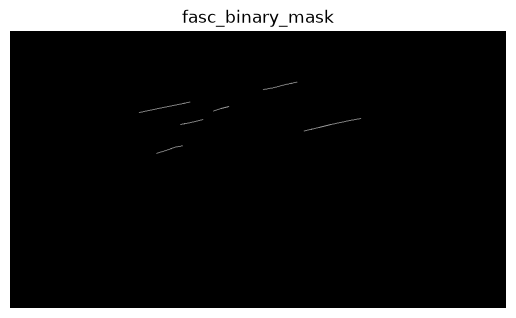

In [24]:
plt.imshow(fasc_binary_mask, cmap="gray")
plt.title("fasc_binary_mask")
plt.axis("off")
plt.show()

## confirmation(確認用)

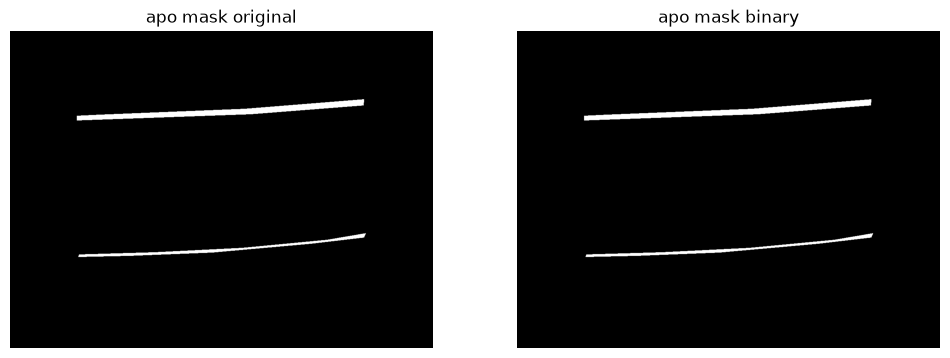

original unique: [  0 255]
binary unique: [0 1]



In [25]:
apo_binary_mask = load_apo_binary_mask(apo_masks_new_model_v1, "image_0000.tif")
compare_original_binary(apo_masks_new_model_v1, "image_0000.tif", apo_binary_mask, "apo mask")

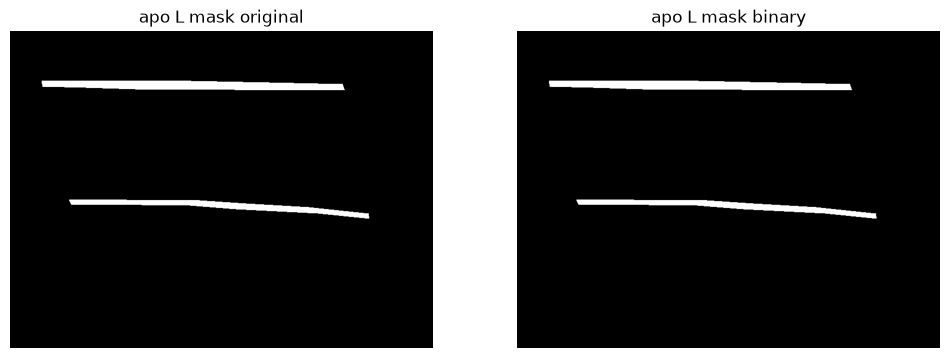

original unique: [  0 255]
binary unique: [0 1]



In [26]:
apo_binary_mask = load_apo_binary_mask(apo_masks_new_model_v1, "image_0428.tif")
compare_original_binary(apo_masks_new_model_v1, "image_0428.tif", apo_binary_mask, "apo L mask")

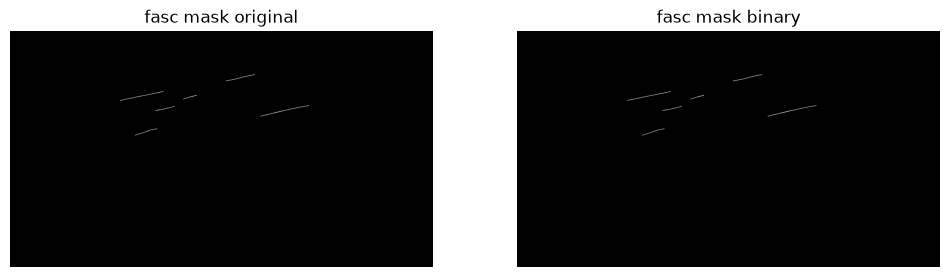

original unique: [  0 255]
binary unique: [0 1]



In [27]:
fasc_binary_mask = load_fasc_binary_mask(fasc_masks_new_model_v1, "image_0000.tif")
compare_original_binary(fasc_masks_new_model_v1, "image_0000.tif", fasc_binary_mask, "fasc mask")

# result (結果)

* apo と fasc の画像・mask構成を確認
* maskの P / L モード差を確認
* 0 / 255 の意味がデータごとに違うことを確認
* それを吸収して、1枚ずつ
```
背景 = 0
目的構造 = 1
```
に統一できる関数を作成
* 変換前後で形状が変わっていないことも確認

<br>

----

<br>

Check the image and mask configuration of apo and fasc
Check the P / L mode difference of mask
Confirm that the meaning of 0 / 255 is different for each data
Absorb it, one piece at a time
background = 0
objective structure = 1
Create a function that can be unified into

Also check that the shape has not changed before and after conversion.